In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("car_evaluation.csv", header= None)
df.head()

,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [3]:
df1 = df.copy()

In [4]:
column_names = ['buying_price', 'maintanence', 'doors', 'persons', 'lug_boot', 'safety', 'class']

In [5]:
df1.columns = column_names
df1.head()

,buying_price,maintanence,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [11]:
df1.isnull().sum()

buying_price    0
maintanence     0
doors           0
persons         0
lug_boot        0
safety          0
class           0
dtype: int64

In [9]:
plt.figure(figsize = (8,8))

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

In [13]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   buying_price  1728 non-null   object
 1   maintanence   1728 non-null   object
 2   doors         1728 non-null   object
 3   persons       1728 non-null   object
 4   lug_boot      1728 non-null   object
 5   safety        1728 non-null   object
 6   class         1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [14]:
df1.describe()

,buying_price,maintanence,doors,persons,lug_boot,safety,class
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [15]:
for i in column_names:
    print(df1[i].value_counts())

buying_price
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
maintanence
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64
persons
2       576
4       576
more    576
Name: count, dtype: int64
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64
safety
low     576
med     576
high    576
Name: count, dtype: int64
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [16]:
from sklearn.preprocessing import LabelEncoder

In [20]:
LE = LabelEncoder()
for i in df1.columns:
    df1[i] = LE.fit_transform(df1[i])

In [22]:
df1.head()

,buying_price,maintanence,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


In [23]:
for i in column_names:
    print(df1[i].value_counts())

buying_price
3    432
0    432
2    432
1    432
Name: count, dtype: int64
maintanence
3    432
0    432
2    432
1    432
Name: count, dtype: int64
doors
0    432
1    432
2    432
3    432
Name: count, dtype: int64
persons
0    576
1    576
2    576
Name: count, dtype: int64
lug_boot
2    576
1    576
0    576
Name: count, dtype: int64
safety
1    576
2    576
0    576
Name: count, dtype: int64
class
2    1210
0     384
1      69
3      65
Name: count, dtype: int64


In [25]:
X = df1.drop('class', axis = 1)
y = df1['class']

In [26]:
print(X.head())
print(y.head())

   buying_price  maintanence  doors  persons  lug_boot  safety
0             3            3      0        0         2       1
1             3            3      0        0         2       2
2             3            3      0        0         2       0
3             3            3      0        0         1       1
4             3            3      0        0         1       2
0    2
1    2
2    2
3    2
4    2
Name: class, dtype: int32


In [27]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size = .3, random_state = 19, stratify  = y)

In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
RF = RandomForestClassifier(n_estimators = 300, random_state = 19, class_weight = 'balanced')

In [30]:
RF.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=19)

In [31]:
y_pred = RF.predict(X_test)

C:\Users\kumar_santhosh\AppData\Local\Temp\ipykernel_18756\3884564379.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(y_test,hist=False,  color="r", label="Actual Value")
C:\Users\kumar_santhosh\AppData\Local\Temp\ipykernel_18756\3884564379.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad637275

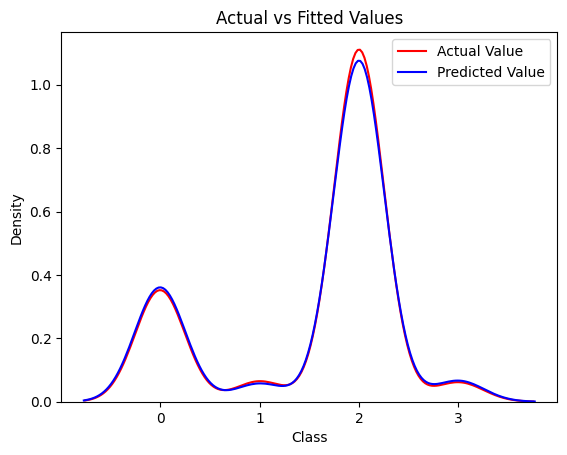

In [81]:
ax1 = sns.distplot(y_test,hist=False,  color="r", label="Actual Value")

sns.distplot(y_pred,color="b",hist=False, label="Fitted Values" , ax=ax1)

plt.title('Actual vs Fitted Values')
plt.xlabel('Class')

plt.legend(['Actual Value', 'Predicted Value'])
plt.show()

In [37]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [38]:
round(accuracy_score(y_test, y_pred)*100, 2)

97.11

In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.94       115
           1       0.89      0.81      0.85        21
           2       0.99      0.98      0.99       363
           3       0.91      1.00      0.95        20

    accuracy                           0.97       519
   macro avg       0.93      0.94      0.93       519
weighted avg       0.97      0.97      0.97       519



In [40]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [42]:
cv_scores = cross_val_score(RF, X, y, cv=10, scoring='accuracy')

In [41]:
skf_cv_scores = cross_val_score(RF, X, y, cv=skf, scoring='accuracy')
print(skf_cv_scores)

[0.97687861 0.99132948 0.97976879 0.97971014 0.98550725]


In [51]:
skf_1 = StratifiedKFold(n_splits=10, shuffle=True, random_state=19)
skf_1_score = cross_val_score(RF, X, y, cv=skf_1, scoring='accuracy')

In [53]:
skf_2 = StratifiedKFold(n_splits=13, shuffle=True, random_state=19)
skf_2_score = cross_val_score(RF, X, y, cv=skf_2, scoring='accuracy')

In [55]:
skf_3 = StratifiedKFold(n_splits=15, shuffle=True, random_state=19)
skf_3_score = cross_val_score(RF, X, y, cv=skf_3, scoring='accuracy')

In [56]:
print(cv_scores.mean())
print(skf_cv_scores.mean())
print(skf_1_score.mean())
print(skf_2_score.mean())
print(skf_3_score.mean())

0.8641080790428821
0.9826388539834129
0.9872563516601692
0.9913069386753596
0.9890104947526237


In [57]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10, 11],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features": ["sqrt", "log2"]
}

In [61]:
grid_search = GridSearchCV(estimator=RF,param_grid=param_grid,cv=skf_2,scoring='accuracy', n_jobs=-1)

In [62]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=13, random_state=19, shuffle=True),
             estimator=RandomForestClassifier(class_weight='balanced',
                                              n_estimators=300,
                                              random_state=19),
             n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 15],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4, 6],
                         'min_samples_split': [2, 5, 10, 11],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [63]:
best_rf = grid_search.best_estimator_
print(best_rf)

RandomForestClassifier(class_weight='balanced', random_state=19)


In [64]:
y_pred_1 = best_rf.predict(X_test)

In [79]:
print("Accuracy:",round(accuracy_score(y_test, y_pred_1)*100, 2))
print(classification_report(y_test, y_pred_1))

Accuracy: 96.92
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       115
           1       0.89      0.81      0.85        21
           2       0.99      0.98      0.99       363
           3       0.91      1.00      0.95        20

    accuracy                           0.97       519
   macro avg       0.93      0.94      0.93       519
weighted avg       0.97      0.97      0.97       519



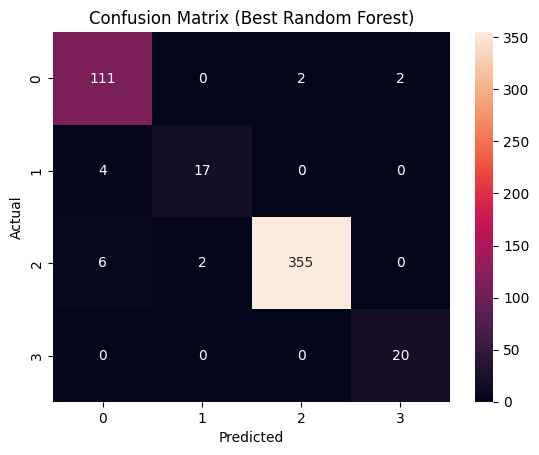

In [67]:
sns.heatmap(confusion_matrix(y_test, y_pred_1), annot=True, fmt='d')
plt.title("Confusion Matrix (Best Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

C:\Users\kumar_santhosh\AppData\Local\Temp\ipykernel_18756\1816907812.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(y_test,hist=False,  color="r", label="Actual Value")
C:\Users\kumar_santhosh\AppData\Local\Temp\ipykernel_18756\1816907812.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad637275

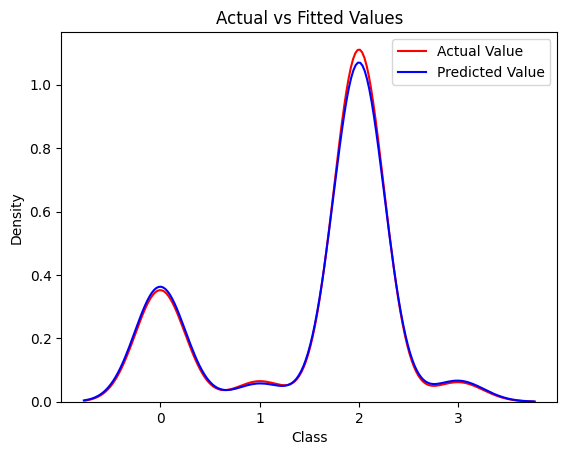

In [80]:
ax1 = sns.distplot(y_test,hist=False,  color="r", label="Actual Value")

sns.distplot(y_pred_1,color="b",hist=False, label="Fitted Values" , ax=ax1)

plt.title('Actual vs Fitted Values')
plt.xlabel('Class')
plt.legend(['Actual Value', 'Predicted Value'])
plt.show()

In [72]:
importances = best_rf.feature_importances_
print(importances)

[0.22199735 0.16294305 0.06547535 0.14965949 0.16720508 0.23271968]


In [74]:
indices = np.argsort(importances)[::-1]
print(indices)

[5 0 4 1 3 2]


C:\Users\kumar_santhosh\AppData\Local\Temp\ipykernel_18756\2603800808.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette='coolwarm')


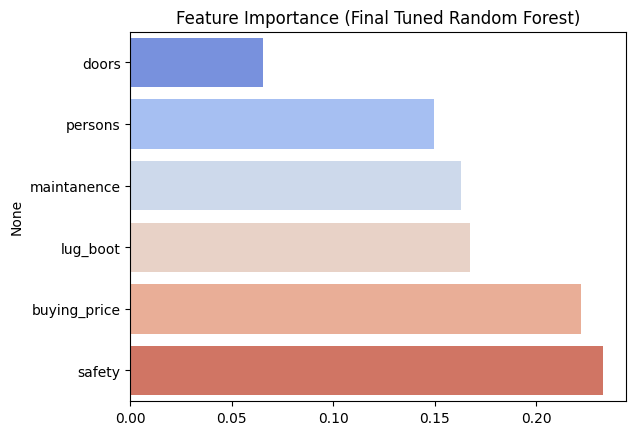

In [76]:
sns.barplot(x=importances[indices], y=X.columns[indices], palette='coolwarm')
plt.title("Feature Importance (Final Tuned Random Forest)")
plt.show()

In [82]:
import joblib
joblib.dump(best_rf, "random_forest_model.joblib")

['random_forest_model.joblib']